# L10b · Tissue Classification in Histopathology and Stain Shift

*Companion notebook for Lecture 10 — Medical Image Analysis (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Train a small CNN to classify colorectal tissue patches (H&E stain) into nine tissue types.
2. Compare accuracy on patches from the **training center** with patches from **another center**.
3. Simulate a stain (color) shift, like a different lab protocol or scanner, and measure the drop.
4. Mitigate it with **stain color augmentation** and with a simple **stain normalization** (Reinhard), and compare.

**Runtime:** about 1.5 minutes on a CUDA GPU and 4–6 minutes on an Apple-silicon laptop (MPS); about 12 minutes on a
4-thread CPU (three CNNs × 8 epochs on a 20,000-patch subset). On a CPU, use a smaller subset (e.g. 10,000) for a quicker run.

In [1]:
import sys, pathlib, time, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.color import rgb2lab, lab2rgb
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from course_utils import seed_everything, plot_style, download, device, DATA

rng = seed_everything(0)
plot_style()
dev = device()
print("device:", dev)

device: cuda


## 1. Dataset: PathMNIST (colorectal cancer histology)

- **What is measured:** tissue sections stained with **hematoxylin and eosin (H&E)**. Hematoxylin colors nuclei
  blue–purple; eosin colors cytoplasm and extracellular matrix pink. Slides are digitized by a slide scanner, so each
  pixel is an RGB color of light transmitted through stained tissue.
- **One sample:** one small image patch cut from a whole-slide image (original 224 × 224 pixels, here downsampled to 28 × 28 × 3).
- **Target:** one of 9 tissue classes: adipose, background, debris, lymphocytes, mucus, smooth muscle,
  normal colon mucosa, cancer-associated stroma, colorectal adenocarcinoma epithelium.
- **Why it matters:** mapping tissue types across a slide is a building block for tumor detection and for
  prognostic scores (Kather et al. derived a stroma-based score associated with survival).
- **Splits:** training/validation patches come from NCT-CRC-HE-100K; the **test set is CRC-VAL-HE-7K, patches from a
  different clinical center** (Kather et al., *PLOS Medicine* 16, e1002730, 2019).

Source: MedMNIST v2 (Yang et al., *Scientific Data* 10, 41, 2023), license CC BY 4.0. Download ≈ 206 MB (Zenodo).

In [2]:
path = download("https://zenodo.org/records/10519652/files/pathmnist.npz?download=1", "pathmnist.npz", timeout=600)
z = np.load(path)
classes = ["adipose", "background", "debris", "lymphocytes", "mucus", "smooth muscle",
           "normal mucosa", "stroma", "tumor epithelium"]
Xtr_all, ytr_all = z["train_images"], z["train_labels"].ravel()
Xva_all, yva_all = z["val_images"], z["val_labels"].ravel()
Xte, yte = z["test_images"], z["test_labels"].ravel()
print("train", Xtr_all.shape, " val", Xva_all.shape, " test", Xte.shape)

# a stratified-by-chance random subset keeps the notebook fast on a CPU
idx = rng.choice(len(Xtr_all), 20000, replace=False)
Xtr, ytr = Xtr_all[idx], ytr_all[idx]
iv = rng.choice(len(Xva_all), 3000, replace=False)
Xva, yva = Xva_all[iv], yva_all[iv]
print("using", len(Xtr), "training and", len(Xva), "validation patches; all", len(Xte), "test patches")

train (89996, 28, 28, 3)  val (10004, 28, 28, 3)  test (7180, 28, 28, 3)
using 20000 training and 3000 validation patches; all 7180 test patches


## 2. Exploration

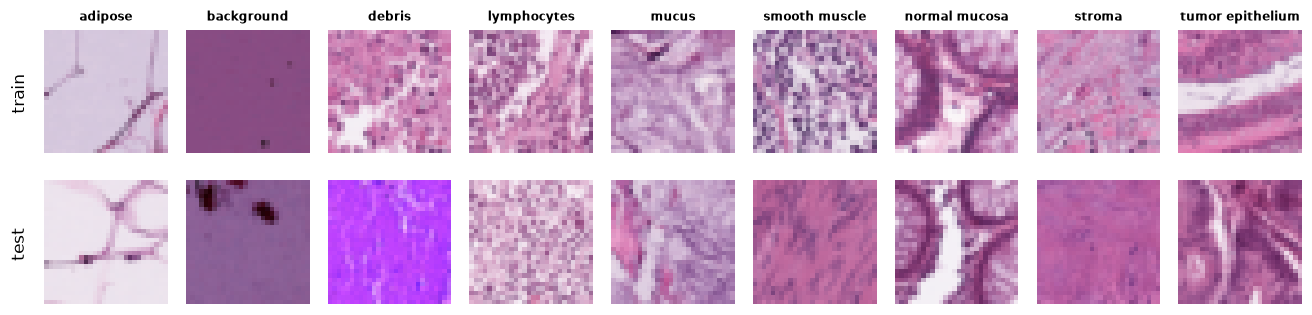

class counts (train subset): [2138 2089 2308 2283 1751 2671 1724 2107 2929]
class counts (test):         [1338  847  339  634 1035  592  741  421 1233]


mean RGB train: [188.8 135.9 180. ]
mean RGB test : [185.3 136.5 180.9]


In [3]:
fig, axes = plt.subplots(2, 9, figsize=(12, 3.2))
for c in range(9):
    for r, (X, y, src) in enumerate([(Xtr, ytr, "train center"), (Xte, yte, "test center")]):
        axes[r, c].imshow(X[np.flatnonzero(y == c)[0]]); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(classes[c], fontsize=8)
axes[0, 0].text(-8, 14, "train", rotation=90, va="center"); axes[1, 0].text(-8, 14, "test", rotation=90, va="center")
plt.tight_layout(); plt.show()

print("class counts (train subset):", np.bincount(ytr, minlength=9))
print("class counts (test):        ", np.bincount(yte, minlength=9))
for name, X in [("train", Xtr), ("test", Xte)]:
    print(f"mean RGB {name:5s}:", np.round(X.reshape(-1, 3).mean(0), 1))

The class proportions differ between centers (e.g., the test set has relatively fewer debris and stroma patches and more adipose), and so does
the average color. We report **balanced accuracy** (mean per-class recall, Lecture 6) alongside accuracy.

## 3. Color in H&E: stain deconvolution
By the Beer–Lambert law, optical density $\mathrm{OD} = -\log(\text{RGB}/255)$ is (approximately) a **linear mix** of
the stain concentrations. Ruifrok & Johnston's color-deconvolution matrix separates OD into hematoxylin (H),
eosin (E) and a residual channel. Changing the stain concentrations and mixing back simulates a slide that was
stained more or less strongly — the main source of color variation between labs.

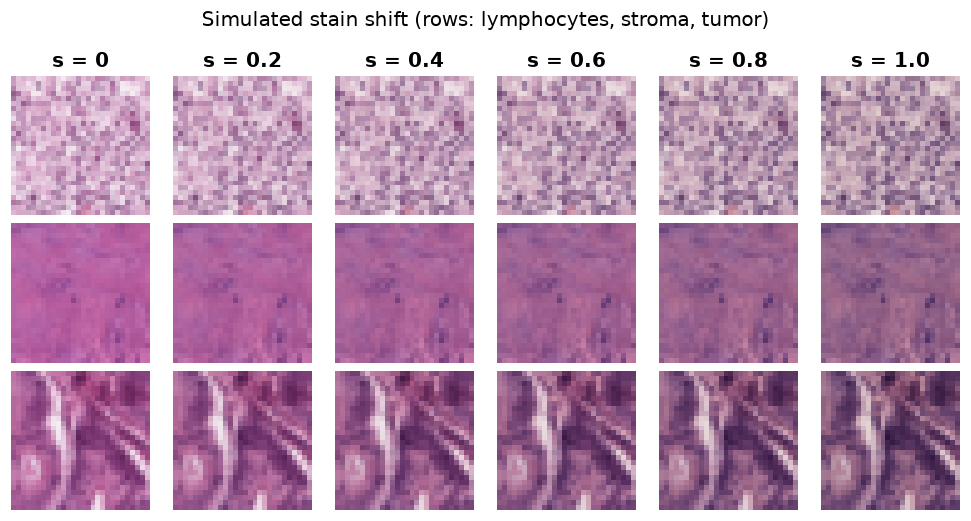

In [4]:
RGB_FROM_HED = torch.tensor([[0.65, 0.70, 0.29], [0.07, 0.99, 0.11], [0.27, 0.57, 0.78]])
HED_FROM_RGB = torch.linalg.inv(RGB_FROM_HED)

def to_tensor(X):                       # uint8 (N, 28, 28, 3) -> float (N, 3, 28, 28) in [0, 1]
    return torch.from_numpy(X).permute(0, 3, 1, 2).float() / 255

def stain_perturb(x, alpha, beta):
    """x: (N,3,H,W) RGB in [0,1]; alpha, beta: (N,3) scale / shift of the H, E, residual concentrations."""
    od = -torch.log(x.clamp_min(1 / 255))                           # optical density
    hed = torch.einsum("nchw,cd->ndhw", od, HED_FROM_RGB.to(x.device))
    hed = hed * alpha[:, :, None, None] + beta[:, :, None, None]
    od2 = torch.einsum("ndhw,dc->nchw", hed, RGB_FROM_HED.to(x.device))
    return torch.exp(-od2).clamp(0, 1)

def shift(x, s):
    """Deterministic 'other lab' shift of strength s: stronger hematoxylin, weaker eosin, a slight tint."""
    n = len(x)
    alpha = torch.tensor([1 + s, 1 - 0.6 * s, 1.0]).repeat(n, 1)
    beta = torch.tensor([0.0, 0.0, 0.15 * s]).repeat(n, 1)
    return stain_perturb(x, alpha, beta)

Tte = to_tensor(Xte)
fig, axes = plt.subplots(3, 6, figsize=(9, 4.8))
ex = [np.flatnonzero(yte == c)[0] for c in (3, 7, 8)]
for r, i in enumerate(ex):
    for c, s in enumerate([0, 0.2, 0.4, 0.6, 0.8, 1.0]):
        axes[r, c].imshow(shift(Tte[i:i + 1], s)[0].permute(1, 2, 0)); axes[r, c].axis("off")
        if r == 0: axes[r, c].set_title(f"s = {s}")
plt.suptitle("Simulated stain shift (rows: lymphocytes, stroma, tumor)"); plt.tight_layout(); plt.show()

## 4. Model: a small CNN
Three convolutional blocks (conv 3×3 → batch norm → ReLU → max-pool), global average pooling and a linear layer — the
L09 recipe. About 140k parameters.

In [5]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=9, c=32):
        super().__init__()
        def blk(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(),
                                 nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(blk(3, c), blk(c, 2 * c), blk(2 * c, 2 * c))
        self.fc = nn.Linear(2 * c, n_classes)

    def forward(self, x):
        return self.fc(self.features(x).mean((2, 3)))

print(f"{sum(p.numel() for p in SmallCNN().parameters()):,} parameters")

140,649 parameters


## 5. Training: three variants
1. **Baseline:** random flips and 90° rotations only (tissue has no preferred orientation).
2. **+ Stain augmentation:** additionally, every training patch gets random H/E/residual scales $\alpha\sim U(0.6, 1.4)$
   and offsets $\beta\sim U(-0.1, 0.1)$ (in the spirit of Tellez et al., 2019), plus random brightness.
3. **Stain normalization:** map every patch (train *and* test) to the same color statistics before the model sees it
   (Reinhard: match per-image mean and standard deviation in the Lab color space to a reference).

In [6]:
def reinhard_stats(X):
    lab = rgb2lab(X.reshape(-1, 28, 3) if X.ndim == 3 else X)
    return lab.reshape(-1, 3).mean(0), lab.reshape(-1, 3).std(0)

REF_MEAN, REF_STD = reinhard_stats(Xtr[:2000])        # reference: statistics of (a subset of) the training data

def reinhard(x):
    """x: torch (N,3,H,W) in [0,1] -> each image matched to the reference Lab mean/std."""
    arr = x.permute(0, 2, 3, 1).numpy()
    lab = rgb2lab(arr)
    m = lab.mean((1, 2), keepdims=True); s = lab.std((1, 2), keepdims=True) + 1e-6
    lab = (lab - m) / s * REF_STD + REF_MEAN
    with warnings.catch_warnings():          # a few out-of-gamut colors are clipped; that is expected
        warnings.simplefilter("ignore", UserWarning)
        rgb = np.clip(lab2rgb(lab), 0, 1)
    return torch.from_numpy(rgb).permute(0, 3, 1, 2).float()

def geo_aug(x, g):
    k = int(g.integers(4))
    x = torch.rot90(x, k, (2, 3))
    return x.flip(3) if g.random() < 0.5 else x

def color_aug(x, g):
    n = len(x)
    alpha = torch.from_numpy(g.uniform(0.6, 1.4, (n, 3))).float().to(x.device)
    beta = torch.from_numpy(g.uniform(-0.1, 0.1, (n, 3))).float().to(x.device)
    x = stain_perturb(x, alpha, beta)
    bright = torch.from_numpy(g.uniform(0.9, 1.1, (n, 1, 1, 1))).float().to(x.device)
    return (x * bright).clamp(0, 1)

MEAN = torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)

def fit(variant, epochs=8, bs=128, lr=2e-3, seed=0):
    seed_everything(seed); g = np.random.default_rng(seed)
    model = SmallCNN().to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, lr, total_steps=epochs * (len(Xtr) // bs))
    T = to_tensor(Xtr)
    if variant == "normalize":
        T = reinhard(T)
    Y = torch.from_numpy(ytr).long()
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for b in np.array_split(g.permutation(len(T)), len(T) // bs):
            x, y = T[b].to(dev), Y[b].to(dev)
            x = geo_aug(x, g)
            if variant == "augment":
                x = color_aug(x, g)
            loss = F.cross_entropy(model(x - MEAN.to(dev)), y)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    print(f"{variant:10s} trained in {time.time() - t0:.0f}s")
    return model

@torch.no_grad()
def predict(model, T, bs=1024):
    model.eval()
    return np.concatenate([model(T[i:i + bs].to(dev) - MEAN.to(dev)).argmax(1).cpu().numpy()
                           for i in range(0, len(T), bs)])

models = {v: fit(v) for v in ["baseline", "augment", "normalize"]}

baseline   trained in 14s


augment    trained in 14s


normalize  trained in 14s


## 6. Evaluation: same center vs other center vs simulated stain shift

In [7]:
Tva = to_tensor(Xva)
strengths = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
res = {v: {} for v in models}
for v, m in models.items():
    prep = reinhard if v == "normalize" else (lambda t: t)
    p_va = predict(m, prep(Tva))
    res[v]["val_acc"] = float((p_va == yva).mean())
    for s in strengths:
        p = predict(m, prep(shift(Tte, s)))
        res[v][f"test_acc_s{s}"] = float((p == yte).mean())
        res[v][f"test_bacc_s{s}"] = float(balanced_accuracy_score(yte, p))

print(f"{'model':10s} {'val (same center)':>18s} " + " ".join(f"{'s=' + str(s):>7s}" for s in strengths))
for v in models:
    print(f"{v:10s} {res[v]['val_acc']:18.3f} " + " ".join(f"{res[v][f'test_acc_s{s}']:7.3f}" for s in strengths))
print("(columns s = ...: accuracy on the other-center test set with simulated stain shift of strength s)")

model       val (same center)   s=0.0   s=0.2   s=0.4   s=0.6   s=0.8   s=1.0
baseline                0.949   0.863   0.782   0.596   0.396   0.317   0.260
augment                 0.925   0.911   0.910   0.903   0.891   0.874   0.856
normalize               0.939   0.902   0.901   0.896   0.889   0.882   0.871
(columns s = ...: accuracy on the other-center test set with simulated stain shift of strength s)


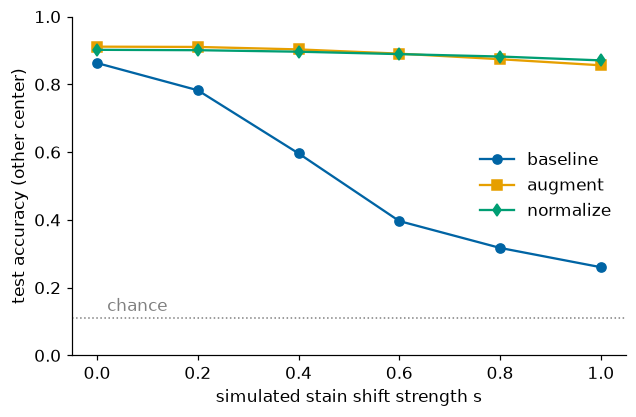

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for v, mk in zip(models, "osd"):
    ax.plot(strengths, [res[v][f"test_acc_s{s}"] for s in strengths], mk + "-", label=v)
ax.set(xlabel="simulated stain shift strength s", ylabel="test accuracy (other center)", ylim=(0, 1))
ax.axhline(1 / 9, color="gray", ls=":", lw=1); ax.text(0.02, 1 / 9 + 0.02, "chance", color="gray")
ax.legend(); plt.show()

Three things to notice:
1. Even with **no** simulated shift, accuracy on the other center's patches is lower than on same-center validation
   patches: that gap is a real **domain shift** between two labs.
2. The baseline degrades quickly as the stain shift grows, while the per-patch class content is unchanged — a
   pathologist would label these patches the same way.
3. Color augmentation and normalization make the model much less sensitive. Neither is free: augmentation can
   remove color cues that are genuinely informative, and normalization can fail on unusual slides.

**Numbers vs the lecture slides.** The slides use a run on an Apple-silicon GPU (MPS): same center / other center /
other center + s = 0.6 = 0.943 / 0.858 / 0.456 (baseline), 0.927 / 0.916 / 0.891 (+ stain augmentation) and
0.937 / 0.900 / 0.890 (Reinhard normalization). The same code and seeds on a 4-thread CPU gave 0.950 / 0.861 / 0.391,
0.925 / 0.916 / 0.893 and 0.940 / 0.898 / 0.889; the executed copy (NVIDIA RTX PRO 6000 GPU) gave 0.949 / 0.863 / 0.396,
0.925 / 0.911 / 0.891 and 0.939 / 0.902 / 0.889. Floating-point differences
between devices change the training trajectory slightly. Most values agree within 0.01; the baseline at s = 0.6 sits
on the steep part of its curve, so small changes in the model move it by several points (0.39–0.46). The
conclusion is the same: the baseline collapses under stain shift, augmentation and normalization do not.

### Which classes break?

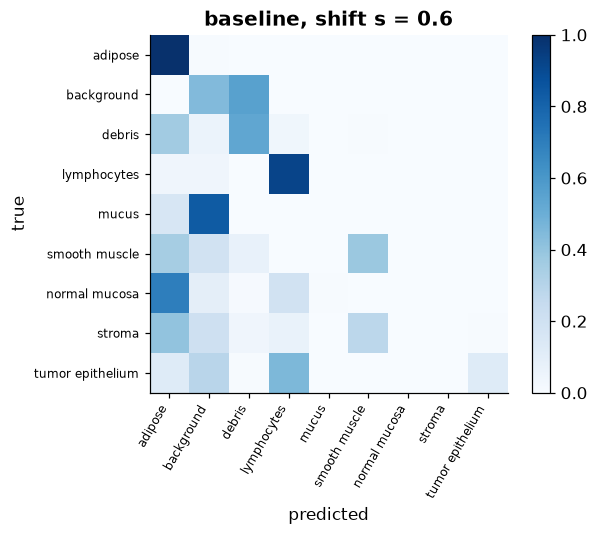

In [9]:
p0 = predict(models["baseline"], shift(Tte, 0.6))
C = confusion_matrix(yte, p0, normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(C, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(9), classes, rotation=60, ha="right", fontsize=8); ax.set_yticks(range(9), classes, fontsize=8)
ax.set(xlabel="predicted", ylabel="true", title="baseline, shift s = 0.6"); plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

## 7. Save a summary (used by the lecture slides)
The L10 deck reads `applications/data/L10b_results.json` when it is built; re-running this notebook overwrites it
with the numbers of your run (keep the keys unchanged).

In [10]:
summary = {"n_train": int(len(Xtr)), "n_val": int(len(Xva)), "n_test": int(len(Xte)),
           "n_params": int(sum(p.numel() for p in SmallCNN().parameters())),
           "strengths": strengths, "results": res, "device": str(dev)}
(DATA / "L10b_results.json").write_text(json.dumps(summary, indent=1))
print(json.dumps({v: {k: round(x, 3) for k, x in r.items() if "bacc" not in k} for v, r in res.items()}, indent=1))

{
 "baseline": {
  "val_acc": 0.949,
  "test_acc_s0.0": 0.863,
  "test_acc_s0.2": 0.782,
  "test_acc_s0.4": 0.596,
  "test_acc_s0.6": 0.396,
  "test_acc_s0.8": 0.317,
  "test_acc_s1.0": 0.26
 },
 "augment": {
  "val_acc": 0.925,
  "test_acc_s0.0": 0.911,
  "test_acc_s0.2": 0.91,
  "test_acc_s0.4": 0.903,
  "test_acc_s0.6": 0.891,
  "test_acc_s0.8": 0.874,
  "test_acc_s1.0": 0.856
 },
 "normalize": {
  "val_acc": 0.939,
  "test_acc_s0.0": 0.902,
  "test_acc_s0.2": 0.901,
  "test_acc_s0.4": 0.896,
  "test_acc_s0.6": 0.889,
  "test_acc_s0.8": 0.882,
  "test_acc_s1.0": 0.871
 }
}


## 8. Interpretation and caveats
- The simulated shift is a **stress test**, not a model of any specific lab. Real between-site differences also
  include tissue preparation, section thickness, scanner optics and compression, and patient populations.
- A test set from the training center (our validation split) overestimates performance at a new hospital. The
  convincing evaluation is on **slides from sites and scanners never used for training**, split by patient.
- Patches from the same slide are highly correlated; in NCT-CRC-HE-100K many patches come from each slide, so any
  train/validation split *within* that set is optimistic. The external test set avoids this.

## 9. Try it yourself
1. Train on the **full** 90k training set (GPU recommended). Does the gap between centers shrink?
2. Make the augmentation range wider ($\alpha\sim U(0.3, 1.7)$). Does in-distribution accuracy drop?
3. Design a different shift (e.g., weaker hematoxylin, blur to mimic an out-of-focus scanner) and test all three models.
4. Combine normalization **and** augmentation. Is it better than either alone?
5. *(CS284A)* Replace Reinhard with Macenko normalization (estimate the two stain vectors per image by SVD of OD).